<a href="https://colab.research.google.com/github/chaymaebouabdellah24-tech/SunPath-Predictor/blob/main/SunPath_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installer XGBoost
!pip install xgboost

In [2]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [3]:
#Charger les datasets
generation = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [ ]:
#Explorer les données
generation.head()
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [20]:
#Convertir les dates
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [21]:
#faire le megre
data = pd.merge(generation, weather, on='DATE_TIME', how='inner')

print(data.shape)

(68774, 12)


In [22]:
#Vérifier le dataset final
data.head()
data.shape

(68774, 12)

In [23]:
#Convertir la date
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'])

In [24]:
#Créer des variables temporelles
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

In [25]:
#Choisir les variables (features)
X = data[['IRRADIATION',
          'AMBIENT_TEMPERATURE',
          'MODULE_TEMPERATURE',
          'hour']]

In [26]:
#Variable cible
y = data['AC_POWER']

In [27]:
#Séparer Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [29]:
#Evaluation Linear Regression
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 26.2979657748521
R2: 0.9800290556767175


In [30]:
#Random Forest
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [31]:
#Evaluation Random Forest
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 16.373826102417915
R2: 0.9865280532472372


In [32]:
#XGBoost
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [33]:
#Evaluation XGBoost
print("XGBoost")

print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2:", r2_score(y_test, pred_xgb))

XGBoost
MAE: 16.633382073934325
R2: 0.986531205412942


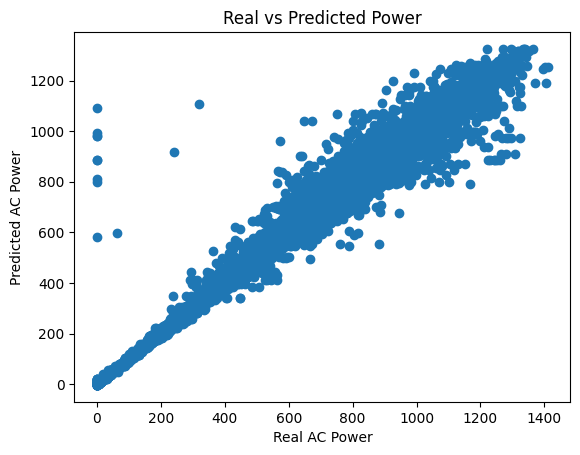

In [34]:
#Visualiser les prédictions
plt.scatter(y_test, pred_xgb)
plt.xlabel("Real AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Real vs Predicted Power")
plt.show()

In [35]:
#Import Deep Learning
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import MinMaxScaler

In [36]:
#Normaliser les données
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [37]:
#Transformer les données en séquences
def create_sequences(X, y, time_steps=10):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(pd.DataFrame(X_scaled), y)

In [38]:
#Split Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [39]:
#Modèle RNN
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#Entrainer le modèle RNN
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 45546.7891 - mae: 96.5157 - val_loss: 7622.3740 - val_mae: 38.4936
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7720.0811 - mae: 40.1445 - val_loss: 7623.6724 - val_mae: 41.4606
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7854.0259 - mae: 40.5143 - val_loss: 6959.9951 - val_mae: 38.0018
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7902.3174 - mae: 40.3402 - val_loss: 7597.8374 - val_mae: 41.3083
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7439.4756 - mae: 39.2932 - val_loss: 7345.8237 - val_mae: 40.7260
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7441.6860 - mae: 39.1531 - val_loss: 6775.7900 - val_mae: 37.2428
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7334.7100 - mae: 38.4406 - val_loss: 6567.5312 - val_mae: 36.5870
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7261.9375 - mae: 39.0777 - val_loss: 6687

In [41]:
#Modèle LSTM
model_lstm = Sequential()

model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#Entrainer le modèle LSTM
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 45692.4961 - mae: 98.3360 - val_loss: 6974.4067 - val_mae: 38.1098
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 7444.1060 - mae: 39.6027 - val_loss: 11484.2578 - val_mae: 56.5136
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 7645.8979 - mae: 40.0772 - val_loss: 6932.1001 - val_mae: 38.5200
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 7517.9058 - mae: 39.7515 - val_loss: 6794.8188 - val_mae: 38.0381
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 7211.0757 - mae: 38.5886 - val_loss: 6297.3252 - val_mae: 37.4171
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 7038.1021 - mae: 38.2143 - val_loss: 5927.9946 - val_mae: 33.9602
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 6450.8604 - mae: 35.8162 - val_loss: 5863.5806 - val_mae: 34.8785
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 6323.9487 - mae: 35.9479 - val_l

In [43]:
#Faire une prédiction
predictions = model_lstm.predict(X_test)

print(predictions[:10])

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[ 1.2144069e+03]
 [ 3.1871747e+02]
 [ 6.8850586e+02]
 [ 3.9707513e+02]
 [ 1.1545736e+03]
 [ 1.7280301e+02]
 [-3.1894445e-01]
 [ 3.3870459e+02]
 [ 9.7092748e-02]
 [-4.4723016e-01]]


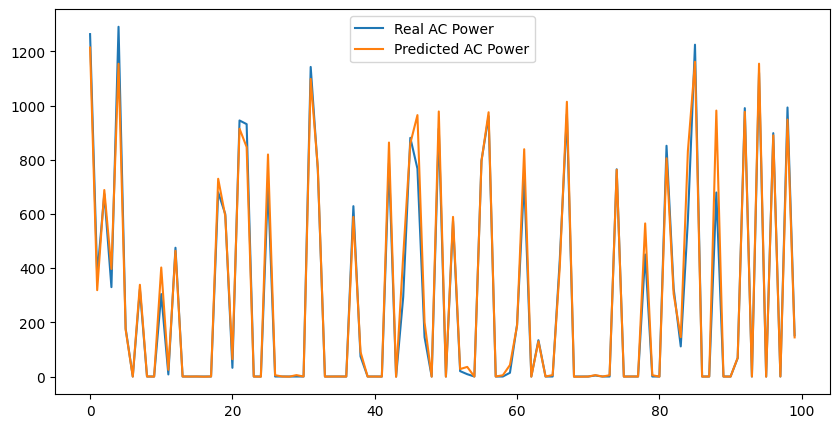

In [44]:
#Graphique pour la soutenance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test[:100], label="Real AC Power")
plt.plot(predictions[:100], label="Predicted AC Power")

plt.legend()
plt.show()